In [48]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math
FREQ = pd.Timedelta(minutes=15)

def parse_dnr(d): 
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)

    # Paths assuming notebook is in src/phasebalance

def make_expected_grid(df, freq=FREQ):
    """Build full expected 15-min grid per (substation, transformer) over its observed span."""
    out = []
    for (sid, tr), g in df.groupby(["substation_id", "transformer"]):
        t0 = g["ts"].min()
        t1 = g["ts"].max()
        grid = pd.date_range(t0, t1, freq=freq)
        out.append(pd.DataFrame({"substation_id": sid, "transformer": tr, "ts": grid}))
    return pd.concat(out, ignore_index=True)


sm_current_path = "../data/smartmeter_15min_all_by_transformer_20250801_20251101_['LPQ_Current_L1_AVG', 'LPQ_Current_L2_AVG', 'LPQ_Current_L3_AVG'].parquet"
jn_current_path = "../data/janitza_3phase_I_by_transformer_20250801_0000_20251101_0000.parquet"

#read data
df_sm_current = pd.read_parquet(sm_current_path)
df_jn_current = pd.read_parquet(jn_current_path)

for d in (df_sm_current, df_jn_current):
    if "transformer" in d.columns:
        d["transformer"] = d["transformer"].astype(str).str.strip().str.lower()


# List of substations / dnr_str values you want to exclude
exclude_dnr = []  # "D0303","D1454" add more here later "D0006", "D1133",
df_jn_current = df_jn_current[~df_jn_current["dnr_str"].isin(exclude_dnr)].copy()

# Add substation_id column by parsing dnr_str
df_jn_current["substation_id"] = df_jn_current["dnr_str"].map(parse_dnr)
df_sm_current = df_sm_current.sort_values(["substation_id", "ts"])
df_jn_current = df_jn_current.sort_values(["substation_id", "ts"])

# Ensure timestamps are timezone-naive UTC
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"], utc=True).dt.tz_localize(None)

# Get the substations that exist in JN (unique substation IDs)
jn_substations = df_jn_current["substation_id"].unique()

# Filter SM to only keep those substations
df_sm_current = df_sm_current[df_sm_current["substation_id"].isin(jn_substations)].copy()   

# Make sure timestamps are the same dtype
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"])

# --- FIX: robust 15-min snapping for Janitza (prevents ceil gaps) ---
tol = pd.Timedelta(seconds=10)  # adjust if needed (1–5s typical)

ts_raw = df_jn_current["ts"]
t_floor = ts_raw.dt.floor("15min")
offset = ts_raw - t_floor

# If just barely after the boundary -> keep boundary, else snap up
df_jn_current["ts"] = t_floor.where(offset <= tol, ts_raw.dt.ceil("15min"))

# Trim both datasets to the same time range
max_ts_sm = df_sm_current["ts"].max()
df_sm_current = df_sm_current[df_sm_current["ts"] < max_ts_sm].copy()
df_jn_current = df_jn_current[df_jn_current["ts"] < max_ts_sm].copy()

# --- FIX: don't drop duplicates (it can delete bins). Aggregate collisions instead ---
jn_cols = ["I_a", "I_b", "I_c", "I_total", "dnr_str"]  # keep what you need
num_cols = ["I_a", "I_b", "I_c", "I_total"]

df_jn_current = (
    df_jn_current
    .groupby(["substation_id", "ts","transformer"], as_index=False)[num_cols]
    .mean()
)

# Build expected grid and mark which bins exist in Janitza
grid = make_expected_grid(df_jn_current, freq=FREQ)
jn_bins = df_jn_current[["substation_id", "ts","transformer"]].drop_duplicates()
grid = grid.merge(jn_bins.assign(jn_present=1), on=["substation_id", "ts","transformer"], how="left")
grid["jn_present"] = grid["jn_present"].fillna(0).astype(int)

# Keep only bins where Janitza exists
good_bins = grid[grid["jn_present"] == 1][["substation_id", "ts","transformer"]]

# Filter both datasets to those bins (so you only compare where Janitza exists)
df_jn_good = df_jn_current.merge(good_bins, on=["substation_id","ts","transformer"], how="inner")
df_sm_good = df_sm_current.merge(good_bins, on=["substation_id","ts","transformer"], how="inner")


print(df_jn_good.shape)
print(df_sm_good.shape)

(716906, 7)
(698399, 9)


In [51]:
key = ["substation_id", "transformer", "ts"]

sm_dupes = df_sm_good.duplicated(key, keep=False).sum()
jn_dupes = df_jn_good.duplicated(key, keep=False).sum()

print("SM duplicate key rows:", sm_dupes)
print("JN duplicate key rows:", jn_dupes)

if sm_dupes:
    print(df_sm_good[df_sm_good.duplicated(key, keep=False)].sort_values(key).head(10))

if jn_dupes:
    print(df_jn_good[df_jn_good.duplicated(key, keep=False)].sort_values(key).head(10))

SM duplicate key rows: 0
JN duplicate key rows: 0


In [52]:
sm_keys = df_sm_good[key].drop_duplicates()
jn_keys = df_jn_good[key].drop_duplicates()

n_sm = len(sm_keys)
n_jn = len(jn_keys)

intersect = sm_keys.merge(jn_keys, on=key, how="inner")
n_int = len(intersect)

print(f"Unique SM keys: {n_sm}")
print(f"Unique JN keys: {n_jn}")
print(f"Intersection:   {n_int}")
print(f"SM coverage in intersection: {n_int/n_sm:.2%}")
print(f"JN coverage in intersection: {n_int/n_jn:.2%}")


Unique SM keys: 698399
Unique JN keys: 716906
Intersection:   698399
SM coverage in intersection: 100.00%
JN coverage in intersection: 97.42%


In [53]:
keys_compare = sm_keys.merge(
    jn_keys,
    on=key,
    how="outer",
    indicator=True
)

print(keys_compare["_merge"].value_counts())

missing_in_jn = keys_compare[keys_compare["_merge"] == "left_only"]
missing_in_sm = keys_compare[keys_compare["_merge"] == "right_only"]

print("\nExample bins present in SM but missing in JN:")
print(missing_in_jn.sort_values(key).head(10))

print("\nExample bins present in JN but missing in SM:")
print(missing_in_sm.sort_values(key).head(10))


_merge
both          698399
right_only     18507
left_only          0
Name: count, dtype: int64

Example bins present in SM but missing in JN:
Empty DataFrame
Columns: [substation_id, transformer, ts, _merge]
Index: []

Example bins present in JN but missing in SM:
        substation_id transformer                  ts      _merge
158298            604         sp2 2025-08-01 00:00:00  right_only
158299            604         sp2 2025-08-01 00:15:00  right_only
158300            604         sp2 2025-08-01 00:30:00  right_only
158301            604         sp2 2025-08-01 00:45:00  right_only
158302            604         sp2 2025-08-01 01:00:00  right_only
158303            604         sp2 2025-08-01 01:15:00  right_only
158304            604         sp2 2025-08-01 01:30:00  right_only
158305            604         sp2 2025-08-01 01:45:00  right_only
158306            604         sp2 2025-08-01 02:00:00  right_only
158307            604         sp2 2025-08-01 02:15:00  right_only


In [45]:

df_merged = df_sm_current.merge(
    df_jn_current,
    on=["substation_id", "ts","transformer"],
    how="inner",             # intersection only
    suffixes=("_sm", "_jn"),
    validate="one_to_one"    # safety check: raises if keys aren't 1:1
)
for col in ["I_a", "I_b", "I_c", "I_total"]:
    df_merged[f"{col}_diff"] = df_merged[f"{col}_sm"] - df_merged[f"{col}_jn"]

df_merged[["I_a_diff", "I_b_diff", "I_c_diff", "I_total_diff"]].describe()

print("SM shape:",df_sm_current.shape)
print("JN shape:",df_jn_current.shape)
print("Merged shape:",df_merged.shape)

SM shape: (714547, 9)
JN shape: (716906, 7)
Merged shape: (698399, 17)


In [39]:
import pandas as pd

def find_time_gaps(df: pd.DataFrame, gap_minutes: int = 30, top_n: int = 20) -> pd.DataFrame:
    """
    Find gaps >= gap_minutes in a (substation_id, ts) time series.
    Assumes ts is already snapped to 15-min grid and aggregated to one row per bin.
    """
    d = df[["substation_id", "ts"]].dropna().copy()
    d["ts"] = pd.to_datetime(d["ts"])
    d = d.sort_values(["substation_id", "ts"])

    d["prev_ts"] = d.groupby("substation_id")["ts"].shift(1)
    d["gap"] = d["ts"] - d["prev_ts"]

    gaps = d[d["gap"] >= pd.Timedelta(minutes=gap_minutes)].copy()
    gaps["missing_bins"] = (gaps["gap"] / pd.Timedelta(minutes=15)).astype(int) - 1
    gaps = gaps.sort_values(["gap", "substation_id"], ascending=[False, True])

    return gaps.head(top_n)

# --- run it on Janitza after your snapping+groupby ---
gaps30 = find_time_gaps(df_jn_current, gap_minutes=30, top_n=50)

print(f"Found {len(gaps30)} gaps >= 30 minutes (showing up to 50).")
display(gaps30[["substation_id", "prev_ts", "ts", "gap", "missing_bins"]])

# Optional: print a tiny timeline around the first gap for sanity
if not gaps30.empty:
    sid = int(gaps30.iloc[0]["substation_id"])
    t0  = gaps30.iloc[0]["prev_ts"]
    t1  = gaps30.iloc[0]["ts"]

    around = df_jn_current[
        (df_jn_current["substation_id"] == sid) &
        (df_jn_current["ts"].between(t0 - pd.Timedelta(minutes=30), t1 + pd.Timedelta(minutes=30)))
    ][["substation_id", "ts", "I_total"]].sort_values("ts")

    print(f"\nExample timeline around first gap (substation {sid}):")
    display(around)


Found 50 gaps >= 30 minutes (showing up to 50).


,substation_id,prev_ts,ts,gap,missing_bins
464327,1413,2025-09-24 01:15:00,2025-09-24 13:00:00,0 days 11:45:00,46
437874,1400,2025-09-24 01:15:00,2025-09-24 12:15:00,0 days 11:00:00,43
567541,1534,2025-08-01 17:00:00,2025-08-01 21:15:00,0 days 04:15:00,16
481406,1454,2025-08-14 01:15:00,2025-08-14 05:00:00,0 days 03:45:00,14
205253,841,2025-08-23 12:00:00,2025-08-23 14:15:00,0 days 02:15:00,8
305447,1299,2025-09-24 06:30:00,2025-09-24 08:45:00,0 days 02:15:00,8
377832,1379,2025-10-12 12:30:00,2025-10-12 14:45:00,0 days 02:15:00,8
483070,1454,2025-09-02 22:15:00,2025-09-03 00:30:00,0 days 02:15:00,8
539213,1508,2025-10-13 09:15:00,2025-10-13 11:30:00,0 days 02:15:00,8
7442,6,2025-10-17 13:00:00,2025-10-17 15:00:00,0 days 02:00:00,7



Example timeline around first gap (substation 1413):


,substation_id,ts,I_total
464324,1413,2025-09-24 00:45:00,571.729965
464325,1413,2025-09-24 01:00:00,593.037781
464326,1413,2025-09-24 01:15:00,633.416672
464327,1413,2025-09-24 13:00:00,1994.540771
464328,1413,2025-09-24 13:15:00,2029.066895
464329,1413,2025-09-24 13:30:00,2245.194763


In [49]:
import pandas as pd

FREQ = pd.Timedelta(minutes=15)

def gap_and_completeness_summary(df_jn: pd.DataFrame, freq: pd.Timedelta = FREQ):
    d = df_jn[["substation_id", "ts"]].dropna().copy()
    d["ts"] = pd.to_datetime(d["ts"])
    d = d.sort_values(["substation_id", "ts"])

    # Gaps
    d["prev_ts"] = d.groupby("substation_id")["ts"].shift(1)
    d["gap"] = d["ts"] - d["prev_ts"]

    gaps = d[d["gap"] > freq].copy()
    gaps["missing_bins"] = (gaps["gap"] / freq).astype("int64") - 1
    gaps["miss_start"] = gaps["prev_ts"] + freq
    gaps["miss_end"]   = gaps["ts"] - freq

    # Completeness per substation over its observed span
    span = (
        d.groupby("substation_id")["ts"]
        .agg(ts_min="min", ts_max="max", n_present="count")
        .reset_index()
    )
    span["n_expected"] = ((span["ts_max"] - span["ts_min"]) / freq).astype("int64") + 1
    span["missing_total_bins"] = (span["n_expected"] - span["n_present"]).astype("int64")
    span["completeness"] = span["n_present"] / span["n_expected"]

    # Gap stats per substation
    if gaps.empty:
        gstats = pd.DataFrame(columns=["substation_id","n_gaps","n_gaps_ge_30m","max_gap","total_missing_bins"])
    else:
        gstats = (
            gaps.groupby("substation_id")
            .agg(
                n_gaps=("gap", "size"),
                n_gaps_ge_30m=("gap", lambda s: (s >= pd.Timedelta(minutes=30)).sum()),
                max_gap=("gap", "max"),
                total_missing_bins=("missing_bins", "sum"),
            )
            .reset_index()
        )

    summary = span.merge(gstats, on="substation_id", how="left")

    # Fill counts with 0, keep as ints
    for c in ["n_gaps", "n_gaps_ge_30m", "total_missing_bins"]:
        summary[c] = summary[c].fillna(0).astype("int64")

    # Fill max_gap with 0 *Timedelta* (THIS was the bug)
    summary["max_gap"] = pd.to_timedelta(summary["max_gap"]).fillna(pd.Timedelta(0))

    # Sort: worst completeness first, then most missing, then biggest single gap
    summary = summary.sort_values(
        ["completeness", "total_missing_bins", "max_gap"],
        ascending=[True, False, False],
    )

    return summary, gaps

summary, gaps = gap_and_completeness_summary(df_jn_current)

display(summary.head(20))
display(gaps.sort_values("gap", ascending=False).head(20)[
    ["substation_id","prev_ts","ts","gap","missing_bins","miss_start","miss_end"]
])


,substation_id,ts_min,ts_max,n_present,n_expected,missing_total_bins,completeness,n_gaps,n_gaps_ge_30m,max_gap,total_missing_bins
52,1413,2025-08-01,2025-10-31 23:45:00,8785,8832,47,0.994678,2,2,0 days 11:45:00,47
49,1400,2025-08-01,2025-10-31 23:45:00,8789,8832,43,0.995131,1,1,0 days 11:00:00,43
64,1534,2025-08-01,2025-10-31 23:45:00,8816,8832,16,0.998188,1,1,0 days 04:15:00,16
6,176,2025-08-01,2025-10-31 23:45:00,8816,8832,16,0.998188,3,3,0 days 02:00:00,16
34,1299,2025-08-01,2025-10-31 23:45:00,8817,8832,15,0.998302,2,2,0 days 02:15:00,15
42,1379,2025-08-01,2025-10-31 23:45:00,8817,8832,15,0.998302,2,2,0 days 02:15:00,15
0,6,2025-08-01,2025-10-31 23:45:00,8822,8832,10,0.998868,3,3,0 days 02:00:00,10
63,1532,2025-08-01,2025-10-31 23:45:00,8822,8832,10,0.998868,2,2,0 days 01:45:00,10
16,615,2025-08-01,2025-10-31 23:45:00,8823,8832,9,0.998981,2,2,0 days 02:00:00,9
23,841,2025-08-01,2025-10-31 23:45:00,8824,8832,8,0.999094,1,1,0 days 02:15:00,8


,substation_id,prev_ts,ts,gap,missing_bins,miss_start,miss_end
464327,1413,2025-09-24 01:15:00,2025-09-24 13:00:00,0 days 11:45:00,46,2025-09-24 01:30:00,2025-09-24 12:45:00
437874,1400,2025-09-24 01:15:00,2025-09-24 12:15:00,0 days 11:00:00,43,2025-09-24 01:30:00,2025-09-24 12:00:00
559864,1534,2025-08-01 17:00:00,2025-08-01 21:15:00,0 days 04:15:00,16,2025-08-01 17:15:00,2025-08-01 21:00:00
377832,1379,2025-10-12 12:30:00,2025-10-12 14:45:00,0 days 02:15:00,8,2025-10-12 12:45:00,2025-10-12 14:30:00
531536,1508,2025-10-13 09:15:00,2025-10-13 11:30:00,0 days 02:15:00,8,2025-10-13 09:30:00,2025-10-13 11:15:00
305447,1299,2025-09-24 06:30:00,2025-09-24 08:45:00,0 days 02:15:00,8,2025-09-24 06:45:00,2025-09-24 08:30:00
205253,841,2025-08-23 12:00:00,2025-08-23 14:15:00,0 days 02:15:00,8,2025-08-23 12:15:00,2025-08-23 14:00:00
305476,1299,2025-09-24 15:45:00,2025-09-24 17:45:00,0 days 02:00:00,7,2025-09-24 16:00:00,2025-09-24 17:30:00
7442,6,2025-10-17 13:00:00,2025-10-17 15:00:00,0 days 02:00:00,7,2025-10-17 13:15:00,2025-10-17 14:45:00
58241,176,2025-09-24 19:15:00,2025-09-24 21:15:00,0 days 02:00:00,7,2025-09-24 19:30:00,2025-09-24 21:00:00


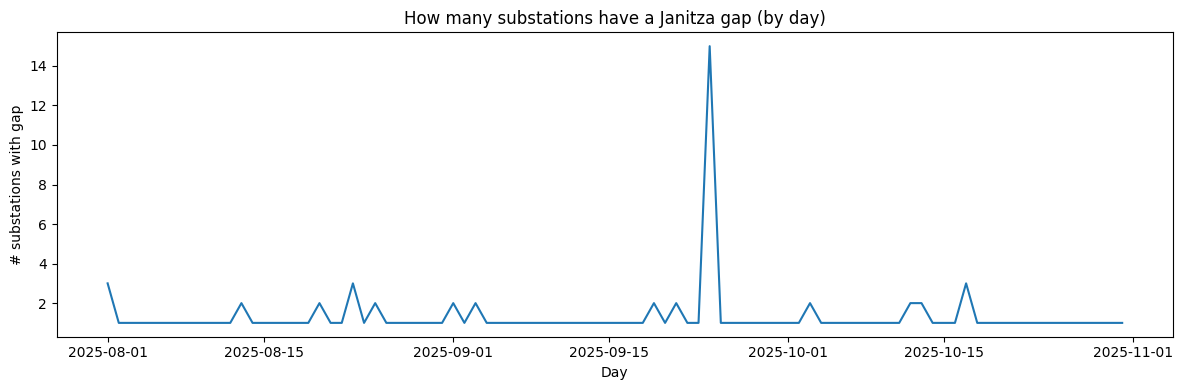

,day,n_substations_with_gap
54,2025-09-24,15
0,2025-08-01,3
77,2025-10-17,3
22,2025-08-23,3
51,2025-09-21,2
63,2025-10-03,2
33,2025-09-03,2
31,2025-09-01,2
49,2025-09-19,2
72,2025-10-12,2


In [42]:
import matplotlib.pyplot as plt

g = gaps.copy()
g["day"] = g["prev_ts"].dt.floor("D")

# how many substations had a gap start on each day
by_day = g.groupby("day")["substation_id"].nunique().reset_index(name="n_substations_with_gap")

plt.figure(figsize=(12,4))
plt.plot(by_day["day"], by_day["n_substations_with_gap"])
plt.title("How many substations have a Janitza gap (by day)")
plt.xlabel("Day")
plt.ylabel("# substations with gap")
plt.tight_layout()
plt.show()

display(by_day.sort_values("n_substations_with_gap", ascending=False).head(15))


In [43]:
bad_day = pd.Timestamp("2025-09-24")

g = gaps.copy()
g["day"] = g["prev_ts"].dt.floor("D")

g_day = (
    g[g["day"] == bad_day]
    .sort_values(["miss_start", "gap"], ascending=[True, False])
    [["substation_id", "prev_ts", "ts", "gap", "missing_bins", "miss_start", "miss_end"]]
)

print(f"Gaps on {bad_day.date()} (n={len(g_day)} rows):")
display(g_day)


Gaps on 2025-09-24 (n=24 rows):


,substation_id,prev_ts,ts,gap,missing_bins,miss_start,miss_end
484829,1454,2025-09-24 00:45:00,2025-09-24 01:15:00,0 days 00:30:00,1,2025-09-24 01:00:00,2025-09-24 01:00:00
464327,1413,2025-09-24 01:15:00,2025-09-24 13:00:00,0 days 11:45:00,46,2025-09-24 01:30:00,2025-09-24 12:45:00
437874,1400,2025-09-24 01:15:00,2025-09-24 12:15:00,0 days 11:00:00,43,2025-09-24 01:30:00,2025-09-24 12:00:00
305447,1299,2025-09-24 06:30:00,2025-09-24 08:45:00,0 days 02:15:00,8,2025-09-24 06:45:00,2025-09-24 08:30:00
484857,1454,2025-09-24 08:00:00,2025-09-24 08:30:00,0 days 00:30:00,1,2025-09-24 08:15:00,2025-09-24 08:15:00
484862,1454,2025-09-24 09:30:00,2025-09-24 10:30:00,0 days 01:00:00,3,2025-09-24 09:45:00,2025-09-24 10:15:00
484864,1454,2025-09-24 10:45:00,2025-09-24 11:30:00,0 days 00:45:00,2,2025-09-24 11:00:00,2025-09-24 11:15:00
484866,1454,2025-09-24 11:45:00,2025-09-24 12:15:00,0 days 00:30:00,1,2025-09-24 12:00:00,2025-09-24 12:00:00
484877,1454,2025-09-24 14:45:00,2025-09-24 15:15:00,0 days 00:30:00,1,2025-09-24 15:00:00,2025-09-24 15:00:00
305476,1299,2025-09-24 15:45:00,2025-09-24 17:45:00,0 days 02:00:00,7,2025-09-24 16:00:00,2025-09-24 17:30:00


Missing substations per 15-min bin on 2025-09-24:


,ts,n_missing_substations
0,2025-09-24 01:00:00,1
1,2025-09-24 01:30:00,2
2,2025-09-24 01:45:00,2
3,2025-09-24 02:00:00,2
4,2025-09-24 02:15:00,2
5,2025-09-24 02:30:00,2
6,2025-09-24 02:45:00,2
7,2025-09-24 03:00:00,2
8,2025-09-24 03:15:00,2
9,2025-09-24 03:30:00,2


,ts,n_missing_substations
42,2025-09-24 11:45:00,2
43,2025-09-24 12:00:00,3
44,2025-09-24 12:15:00,1
45,2025-09-24 12:30:00,1
46,2025-09-24 12:45:00,1
47,2025-09-24 15:00:00,1
48,2025-09-24 16:00:00,13
49,2025-09-24 16:15:00,9
50,2025-09-24 16:30:00,2
51,2025-09-24 16:45:00,2


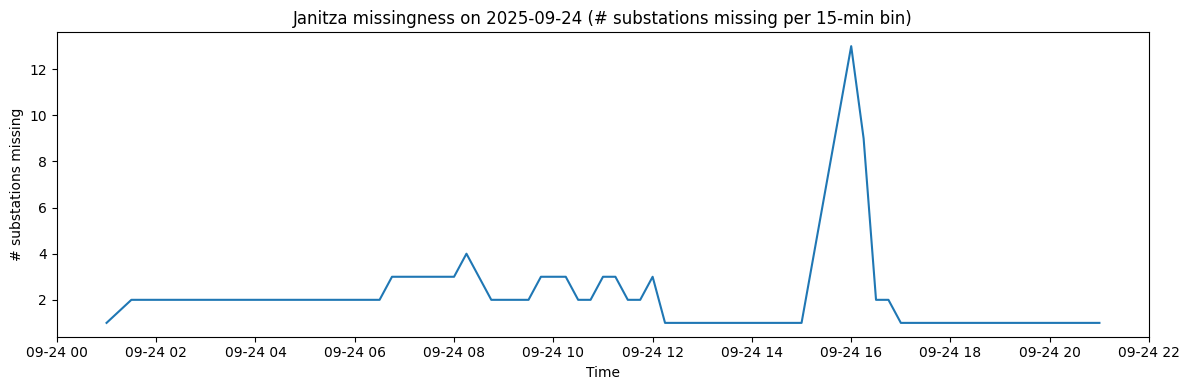

In [45]:
def missing_bins_series(gaps_df: pd.DataFrame, day: pd.Timestamp, freq="15min"):
    g = gaps_df.copy()
    g["day"] = g["prev_ts"].dt.floor("D")
    g = g[g["day"] == day].dropna(subset=["miss_start","miss_end"])

    bins = []
    for sid, a, b in g[["substation_id","miss_start","miss_end"]].itertuples(index=False):
        if b < a:
            continue
        # include endpoints on the missing grid
        ts = pd.date_range(a, b, freq=freq)
        bins.extend((t, sid) for t in ts)

    if not bins:
        return pd.DataFrame(columns=["ts","n_missing_substations"])

    x = pd.DataFrame(bins, columns=["ts","substation_id"])
    s = x.groupby("ts")["substation_id"].nunique().reset_index(name="n_missing_substations")
    return s.sort_values("ts")

miss_0924 = missing_bins_series(gaps, pd.Timestamp("2025-09-24"))

print("Missing substations per 15-min bin on 2025-09-24:")
display(miss_0924.head(20))
display(miss_0924.tail(20))

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(miss_0924["ts"], miss_0924["n_missing_substations"])
plt.title("Janitza missingness on 2025-09-24 (# substations missing per 15-min bin)")
plt.xlabel("Time")
plt.ylabel("# substations missing")
plt.tight_layout()
plt.show()


In [47]:
def contiguous_windows(ts_series: pd.Series, freq=pd.Timedelta(minutes=15)):
    """Given sorted timestamps, return contiguous [start,end] windows."""
    ts = ts_series.sort_values().reset_index(drop=True)
    if ts.empty:
        return []
    starts = [ts.iloc[0]]
    ends = []
    for i in range(1, len(ts)):
        if ts.iloc[i] - ts.iloc[i-1] != freq:
            ends.append(ts.iloc[i-1])
            starts.append(ts.iloc[i])
    ends.append(ts.iloc[-1])
    return list(zip(starts, ends))

threshold = 10
bad_bins = miss_0924[miss_0924["n_missing_substations"] >= threshold]

windows = contiguous_windows(bad_bins["ts"], freq=pd.Timedelta(minutes=15))

print(f"Outage windows on 2025-09-24 where >= {threshold} substations are missing:")
for a, b in windows:
    print(f"  {a}  ->  {b}")


Outage windows on 2025-09-24 where >= 10 substations are missing:
  2025-09-24 16:00:00  ->  2025-09-24 16:00:00


Original: (586269, 6) (591735, 8)
Good-bin: (586269, 6) (586260, 8)


In [56]:
jn_bins = df_jn_current[["substation_id", "ts"]].drop_duplicates()
sm_bins = df_sm_current[["substation_id", "ts"]].drop_duplicates()

jn_only = (
    jn_bins.merge(sm_bins, on=["substation_id", "ts"], how="left", indicator=True)
          .query("_merge == 'left_only'")
          .drop(columns="_merge")
          .sort_values(["substation_id","ts"])
)

print("JN bins missing in SM:", len(jn_only))
display(jn_only)


JN bins missing in SM: 9


,substation_id,ts
404911,1394,2025-10-18 16:30:00
404912,1394,2025-10-18 16:45:00
507470,1484,2025-08-07 16:30:00
507471,1484,2025-08-07 16:45:00
507472,1484,2025-08-07 17:00:00
507473,1484,2025-08-07 17:15:00
507474,1484,2025-08-07 17:30:00
507475,1484,2025-08-07 17:45:00
540767,1525,2025-10-17 15:15:00


In [58]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math

FREQ = pd.Timedelta(minutes=15)

def parse_dnr(d):
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")
    if digits == "":
        return None
    return int(digits)

sm_current_path = "../data/smartmeter_15min_all_from_devices_20250801_20251101_Current.parquet"
jn_current_path = "../data/janitza_3phase_I_all_20250801_0000_20251101_0000.parquet"

# read data
df_sm_current = pd.read_parquet(sm_current_path)
df_jn_current = pd.read_parquet(jn_current_path)

# exclude substations (Janitza side)
exclude_dnr = ["D0303", "D1454"]
df_jn_current = df_jn_current[~df_jn_current["dnr_str"].isin(exclude_dnr)].copy()

# add substation_id
df_jn_current["substation_id"] = df_jn_current["dnr_str"].map(parse_dnr)

# timestamps
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"], utc=True).dt.tz_localize(None)

# keep only substations that exist in Janitza
jn_substations = df_jn_current["substation_id"].dropna().unique()
df_sm_current = df_sm_current[df_sm_current["substation_id"].isin(jn_substations)].copy()

# --- FIX: robust 15-min snapping for Janitza (prevents ceil gaps) ---
tol = pd.Timedelta(seconds=10)

ts_raw = df_jn_current["ts"]
t_floor = ts_raw.dt.floor("15min")
offset = ts_raw - t_floor

df_jn_current["ts"] = t_floor.where(offset <= tol, ts_raw.dt.ceil("15min"))

# trim to same max timestamp (optional but fine)
max_ts_sm = df_sm_current["ts"].max()
df_sm_current = df_sm_current[df_sm_current["ts"] < max_ts_sm].copy()
df_jn_current = df_jn_current[df_jn_current["ts"] < max_ts_sm].copy()

# --- FIX: aggregate Janitza collisions instead of drop_duplicates ---
num_cols = ["I_a", "I_b", "I_c", "I_total"]
df_jn_current = (
    df_jn_current
    .groupby(["substation_id", "ts"], as_index=False)[num_cols]
    .mean()
)

# --- NEW: build COMMON bins (intersection) so both datasets end with same keys ---
jn_bins = df_jn_current[["substation_id", "ts"]].drop_duplicates()
sm_bins = df_sm_current[["substation_id", "ts"]].drop_duplicates()

common_bins = jn_bins.merge(sm_bins, on=["substation_id", "ts"], how="inner")

# filter BOTH to intersection bins
df_jn_good = df_jn_current.merge(common_bins, on=["substation_id", "ts"], how="inner")
df_sm_good = df_sm_current.merge(common_bins, on=["substation_id", "ts"], how="inner")

# sanity checks
print("Original:", df_jn_current.shape, df_sm_current.shape)
print("Common-bin:", df_jn_good.shape, df_sm_good.shape)

# confirm no duplicate keys remain
print("Duplicate keys in JN good:", df_jn_good.duplicated(["substation_id","ts"]).sum())
print("Duplicate keys in SM good:", df_sm_good.duplicated(["substation_id","ts"]).sum())


Original: (586269, 6) (591735, 8)
Common-bin: (586260, 6) (586260, 8)
Duplicate keys in JN good: 0
Duplicate keys in SM good: 0


### Attempt to Solve CT Issue with Fixed CT Ratio Fixes (OLD)
Below is code where I attempt to solve the CT issue with fixed CT ratio fixes. This involves applying a predetermined CT scaling factor to correct the Janitza measurements based on the computed diagnostics.

In [ ]:


# data\janitza_D1364_3phase_I_per_device_20251101_1200_20251103_1200.parquet"
devices_path ="../data/janitza_D1496_3phase_I_per_device_20251101_1200_20251103_1200.parquet"
df_sub = pd.read_parquet(devices_path) # col names are L1 , L2 and L3
df_sub.head()

# Pick the phase columns that exist in your df
phase_cols = [c for c in ["L1","L2","L3"] if c in df_sub.columns]
if not phase_cols:
    phase_cols = [c for c in ["IA","IB","IC"] if c in df_sub.columns]

# 1) CT correction factor (2250/5 -> 1200/5)  => 1200/2250
ct_ratio_wrong = 2250 / 5
ct_ratio_correct = 1200 / 5
correction_factor = ct_ratio_correct / ct_ratio_wrong  # 0.533333...

df_fixed = df_sub.copy()

# 2) Apply correction ONLY to device 386
mask_386 = df_fixed["device_id"] == 386
df_fixed.loc[mask_386, phase_cols] = df_fixed.loc[mask_386, phase_cols] * correction_factor

print(f"Applied correction factor to device 386: {correction_factor:.4f}")

# 3) Optional: recreate df_385 and df_386 like before (aligned on ts)
df_385 = (df_fixed[df_fixed["device_id"] == 385]
          .assign(ts=pd.to_datetime(df_fixed.loc[df_fixed["device_id"] == 385, "ts"]))
          .set_index("ts")[phase_cols])

df_386 = (df_fixed[df_fixed["device_id"] == 386]
          .assign(ts=pd.to_datetime(df_fixed.loc[df_fixed["device_id"] == 386, "ts"]))
          .set_index("ts")[phase_cols])

# Safer than df_385 + df_386 (handles missing timestamps)
df_total = df_385.add(df_386, fill_value=0)
df_total["I_total"] = df_total.sum(axis=1)

# --- compare with smart meter ---
df_sm_1364 = df_sm_current[df_sm_current["substation_id"] == 1364].copy()
df_sm_1364["ts"] = pd.to_datetime(df_sm_1364["ts"])

plt.figure(figsize=(12, 6))
plt.plot(df_sm_1364["ts"], df_sm_1364["I_total"], label="SM Current (Substation 1364)")
plt.plot(df_total.index, df_total["I_total"], label="Total Current (385 + corrected 386)")
plt.xlabel("Time")
plt.ylabel("Current [A]")
plt.title("SM Current for Substation 1364 vs Total Current from 385+386")
plt.legend()
plt.grid(True)
plt.show()
